In [5]:
import yfinance as yf
import pandas as pd
import ta

def get_data(ticker, file_save_name):
    print(f"Đang tải dữ liệu {ticker}...")
    # Lấy dữ liệu từ năm 2020 đến thời điểm hiện tại
    df = yf.download(ticker, start="2020-01-01", end="2026-06-11")
    
    # 1. Chuẩn hóa cấu trúc dữ liệu (Làm phẳng MultiIndex cho mọi cột)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
        
    # 2. Thêm các chỉ báo kỹ thuật (Feature Engineering)
    # Tính RSI (14 phiên)
    df['RSI'] = ta.momentum.rsi(df['Close'], window=14)
    
    # Tính các đường Trung bình động MA (10, 20, 50 phiên)
    df['MA10'] = ta.trend.sma_indicator(df['Close'], window=10)
    df['MA20'] = ta.trend.sma_indicator(df['Close'], window=20)
    df['MA50'] = ta.trend.sma_indicator(df['Close'], window=50)
    
    # Tính MACD
    df['MACD'] = ta.trend.macd_diff(df['Close'])
    
    # 3. Làm sạch dữ liệu
    # Việc tính MA50 sẽ tạo ra 50 dòng NaN đầu tiên, bắt buộc phải xóa bỏ
    df.dropna(inplace=True)
    
    # 4. Lưu ra định dạng CSV chuẩn
    df.to_csv(f'../data/{file_save_name}.csv')
    print(f"Đã lưu dữ liệu sạch vào {file_save_name}.csv với đầy đủ chỉ báo!")
    
    return df

# Thực thi
df_final = get_data("VCB.VN", "VCB_data")

[*********************100%***********************]  1 of 1 completed

Đang tải dữ liệu VCB.VN...
Đã lưu dữ liệu sạch vào VCB_data.csv với đầy đủ chỉ báo!


In [15]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from load_data import load_vcb_data

# 1. Đọc tệp dữ liệu đã tính toán chỉ báo từ Getdata.ipynb
df = load_vcb_data()

# 2. Lọc danh sách các thuộc tính tham gia phân tích toán học
feature_cols = ['Close', 'Volume', 'RSI', 'MA10', 'MA20', 'MA50', 'MACD']
corr_matrix = df[feature_cols].corr()

print("==============================================================")
print("             MA TRẬN TƯƠNG QUAN TUYẾN TÍNH PEARSON            ")
print("==============================================================")
print(corr_matrix.round(4))
print("==============================================================")


             MA TRẬN TƯƠNG QUAN TUYẾN TÍNH PEARSON            
         Close  Volume     RSI    MA10    MA20    MA50    MACD
Close   1.0000 -0.1371  0.2003  0.9863  0.9721  0.9292  0.0161
Volume -0.1371  1.0000  0.0319 -0.1436 -0.1478 -0.1499  0.0475
RSI     0.2003  0.0319  1.0000  0.0802 -0.0022 -0.1244  0.5796
MA10    0.9863 -0.1436  0.0802  1.0000  0.9925  0.9535 -0.1129
MA20    0.9721 -0.1478 -0.0022  0.9925  1.0000  0.9739 -0.1822
MA50    0.9292 -0.1499 -0.1244  0.9535  0.9739  1.0000 -0.1417
MACD    0.0161  0.0475  0.5796 -0.1129 -0.1822 -0.1417  1.0000


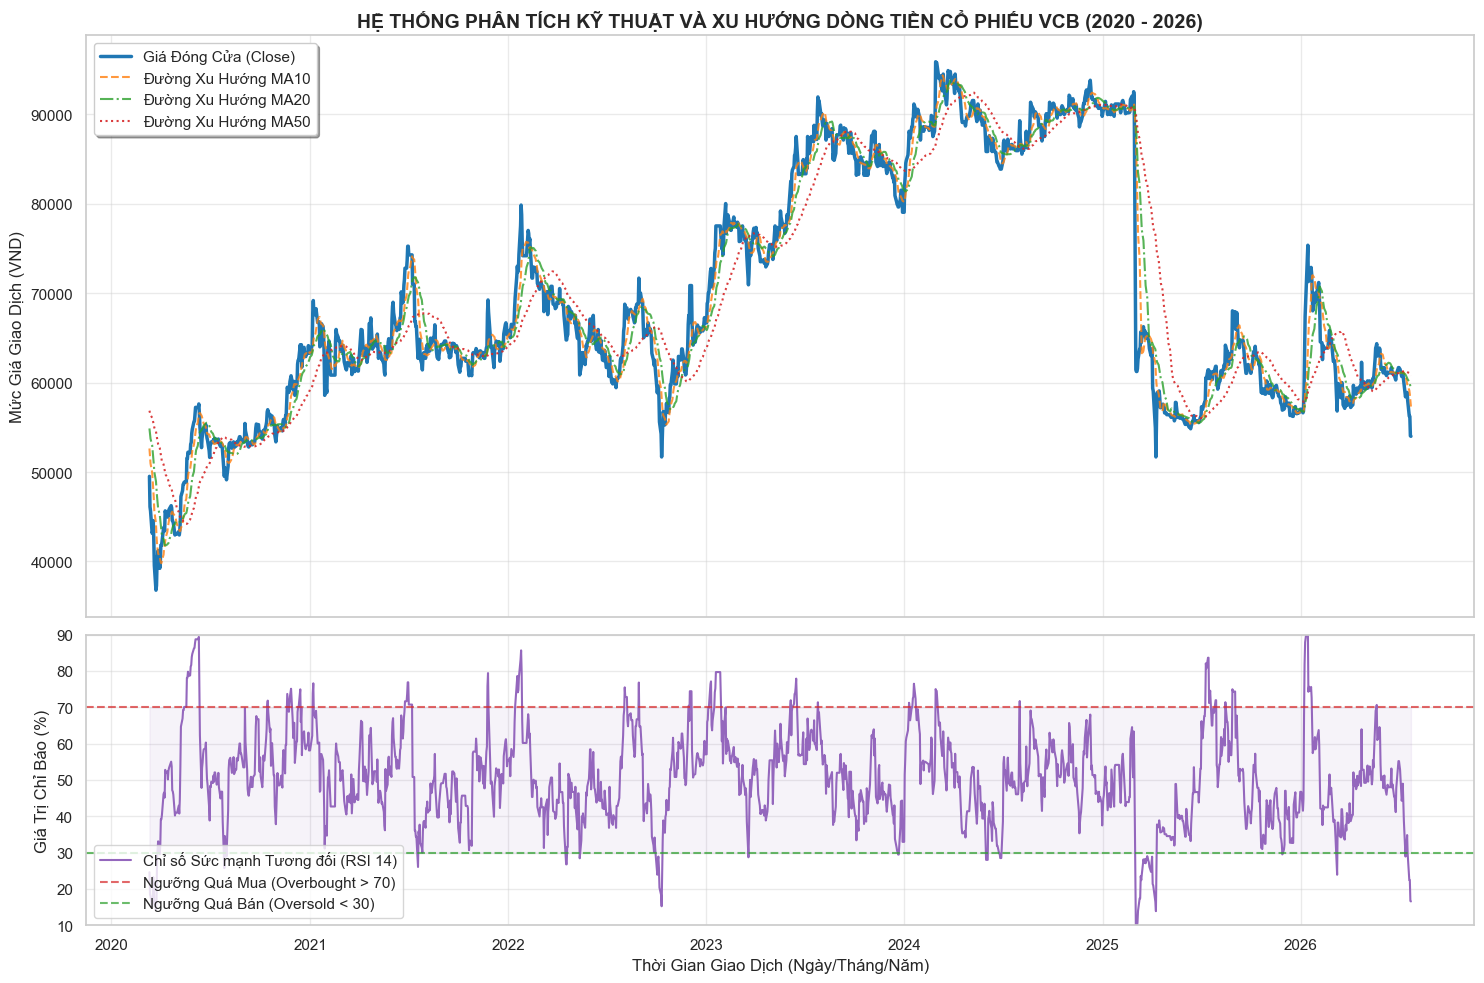

In [16]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from load_data import load_vcb_data

df = load_vcb_data()

# Khởi tạo không gian đồ họa lưới Seaborn phân tầng tỉ lệ 2:1
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True, 
                               gridspec_kw={'height_ratios': [2, 1]})

# Đồ thị 1: Diễn biến giá Close và các dải xu hướng trung bình động (MA)
ax1.plot(df.index, df['Close'], label='Giá Đóng Cửa (Close)', color='#1f77b4', linewidth=2.5)
ax1.plot(df.index, df['MA10'], label='Đường Xu Hướng MA10', color='#ff7f0e', linestyle='--', alpha=0.8)
ax1.plot(df.index, df['MA20'], label='Đường Xu Hướng MA20', color='#2ca02c', linestyle='-.', alpha=0.8)
ax1.plot(df.index, df['MA50'], label='Đường Xu Hướng MA50', color='#d62728', linestyle=':', alpha=0.9)

ax1.set_title('HỆ THỐNG PHÂN TÍCH KỸ THUẬT VÀ XU HƯỚNG DÒNG TIỀN CỔ PHIẾU VCB (2020 - 2026)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Mức Giá Giao Dịch (VND)', fontsize=12)
ax1.legend(loc='upper left', frameon=True, shadow=True, facecolor='white')
ax1.grid(True, alpha=0.4)

# Đồ thị 2: Biến động chỉ báo động lượng RSI và các biên kỹ thuật cố định
ax2.plot(df.index, df['RSI'], label='Chỉ số Sức mạnh Tương đối (RSI 14)', color='#9467bd', linewidth=1.5)
ax2.axhline(70, color='#d62728', linestyle='--', alpha=0.7, label='Ngưỡng Quá Mua (Overbought > 70)')
ax2.axhline(30, color='#2ca02c', linestyle='--', alpha=0.7, label='Ngưỡng Quá Bán (Oversold < 30)')
ax2.fill_between(df.index, 30, 70, color='#9467bd', alpha=0.08) # Tô dải an toàn cho động lượng

ax2.set_xlabel('Thời Gian Giao Dịch (Ngày/Tháng/Năm)', fontsize=12)
ax2.set_ylabel('Giá Trị Chỉ Báo (%)', fontsize=12)
ax2.set_ylim(10, 90)
ax2.legend(loc='lower left', frameon=True, facecolor='white')
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()